In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [61]:
df=pd.read_csv('Crop_recommendation_messy.csv')
df.head()   

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2166 non-null   float64
 1   P            2233 non-null   int64  
 2   K            2233 non-null   int64  
 3   temperature  2233 non-null   float64
 4   humidity     2233 non-null   float64
 5   ph           2166 non-null   float64
 6   rainfall     2166 non-null   float64
 7   label        2233 non-null   str    
dtypes: float64(5), int64(2), str(1)
memory usage: 155.2 KB


In [63]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2166.000000,2233.000000,2233.000000,2233.000000,2233.000000,2166.000000,2166.000000
mean,50.671745,53.319749,48.054635,25.653596,71.442177,6.469634,103.693974
std,37.035740,32.962859,50.533814,5.404484,22.537629,0.775606,55.210597
min,0.000000,5.000000,5.000000,-3.000000,-10.000000,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.750888,60.281630,5.965422,64.242642
50%,37.000000,51.000000,32.000000,25.567030,80.471527,6.422230,95.085968
75%,85.000000,68.000000,48.000000,28.562122,90.006217,6.927889,125.905733
max,140.000000,145.000000,205.000000,55.000000,105.000000,9.935091,298.560117


In [64]:
df.isnull().sum()

N              67
P               0
K               0
temperature     0
humidity        0
ph             67
rainfall       67
label           0
dtype: int64

In [65]:
df=df.dropna()
df['label']=df['label'].str.strip().str.lower()

In [66]:
X=df.drop('label',axis=1)
y=df['label']
le = LabelEncoder()
y = le.fit_transform(y)

In [67]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [68]:
model = RandomForestClassifier( n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
predictions = model.predict(X_test)

In [70]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9926470588235294


In [71]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))  
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [74]:
sample = pd.DataFrame([{
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.8,
    'humidity': 82,
    'ph': 6.5,
    'rainfall': 202
}])

pred = model.predict(sample)

crop = le.inverse_transform(pred)

print(crop)

['rice']


In [75]:
probs = model.predict_proba(sample)
confidence = max(probs[0]) * 100
print("Confidence:", confidence)

Confidence: 100.0


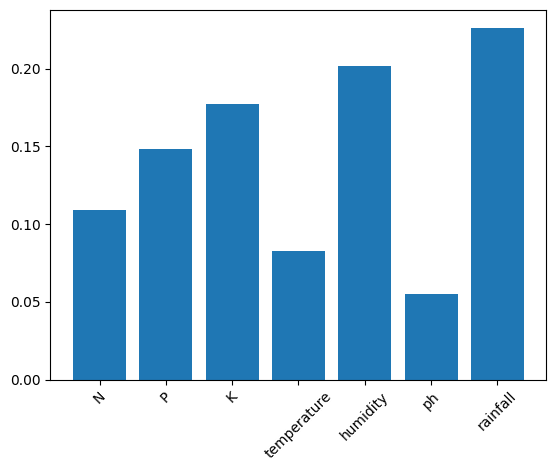

In [76]:
import matplotlib.pyplot as plt
importance = model.feature_importances_
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.show()

In [77]:
df.to_csv("cleaned_crop_data.csv", index=False)